In [ ]:
from data_prep import load_data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
X, y, subj_idx = load_data('data')

In [3]:
# why random forest: minimal overfitting, nonlinear, robust to outliers, faster and easier than svm
model = RandomForestClassifier(random_state=67)
loso = LeaveOneGroupOut()

In [ ]:
subjs = np.unique(subj_idx)
subj_iter = iter(subjs)

CROSS FOLD 0===============
Accuracy: 0.34534534534534533
Precision: 0.23582511129680941
Recall: 0.34070254464991306


/home/patrick/code/Affective Computing/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


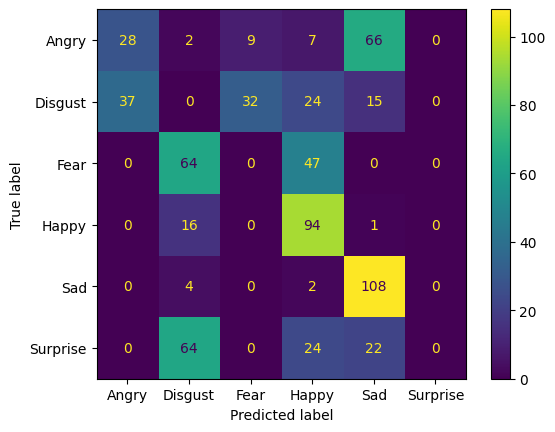

/home/patrick/code/Affective Computing/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


TypeError: write() argument must be str, not numpy.ndarray

In [ ]:
for train, test in loso.split(X, y, groups = subj_idx):
    X_train, X_test = X[train], X[test]
    y_train, y_test = y[train], y[test]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    subj = next(subj_iter)

    print(f'===== CROSS FOLD {subj} ' + ('=' * 10))
    print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
    print(f'Precision: {precision_score(y_test, y_pred, average='micro')}')
    print(f'Recall: {recall_score(y_test, y_pred, average='micro')}')
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    with open('model_results.txt', 'a') as f:
        f.write(f'\n===== CROSS FOLD {subj} ' + ('=' * 10))
        f.write(f'\nAccuracy: {accuracy_score(y_test, y_pred)}')
        f.write(f'\nPrecision: {precision_score(y_test, y_pred, average='macro')}')
        f.write(f'\nRecall: {recall_score(y_test, y_pred, average='macro')}')
        for r in confusion_matrix(y_test, y_pred):
            f.write('\n')
            for c in r:
                f.write(f'[{c}]')

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions
# https://medium.com/@christophermiguelaguirre/defining-a-function-to-create-a-confusion-matrix-from-k-fold-cross-validation-results-8766b81984b0
